# Mini Project: Flight Price Prediction
This notebook builds an end-to-end **regression pipeline** to predict flight prices using `Clean_Dataset.csv`.

> Workflow: data audit → preprocessing → model comparison → diagnostics → save best pipeline.

In [1]:
# 1) Imports and settings
from __future__ import annotations

from pathlib import Path
from time import perf_counter
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import auc, mean_absolute_error, mean_squared_error, r2_score, roc_curve
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.2
# Supposed to be 3, 80000
CV_FOLDS = 0           # Set to 0 or 1 to skip cross-validation
MAX_ROWS = 2000      # Reduce this if runtime is high
USE_LOG_TARGET = False

DATA_PATH = Path('datasets/miniproject/Clean_Dataset.csv')
OUTPUT_DIR = Path('outputs/flight_price')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

## 2) Load and inspect dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype').T)

print('\nMissing values per column:')
display(df.isna().sum().to_frame('missing_count').T)

print('\nDuplicate rows:', df.duplicated().sum())

Shape: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955



Data types:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
dtype,int64,object,object,object,object,object,object,object,object,float64,int64,int64



Missing values per column:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
missing_count,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


## 3) Preprocessing and feature setup

In [3]:
def load_and_prepare_data(df_in: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    df_local = df_in.copy()

    if MAX_ROWS is not None and len(df_local) > MAX_ROWS:
        df_local = df_local.sample(n=MAX_ROWS, random_state=RANDOM_STATE)

    unnamed_cols = [c for c in df_local.columns if c.lower().startswith('unnamed')]
    if unnamed_cols:
        df_local = df_local.drop(columns=unnamed_cols)

    if 'stops' in df_local.columns:
        stop_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
        mapped_stops = df_local['stops'].map(stop_map)
        if mapped_stops.notna().all():
            df_local['stops'] = mapped_stops.astype(int)

    if 'price' not in df_local.columns:
        raise ValueError("Dataset must contain a 'price' column")

    y_local = df_local['price'].astype(float)
    X_local = df_local.drop(columns=['price'])

    constant_cols = [c for c in X_local.columns if X_local[c].nunique(dropna=False) <= 1]
    if constant_cols:
        X_local = X_local.drop(columns=constant_cols)
        print('Dropped constant columns:', constant_cols)

    return X_local, y_local


def build_preprocessor(X_local: pd.DataFrame) -> ColumnTransformer:
    categorical_cols = X_local.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = [c for c in X_local.columns if c not in categorical_cols]

    numeric_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]
    )

    preprocessor_local = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols),
        ]
    )
    return preprocessor_local


def build_models() -> dict[str, object]:
    models_local: dict[str, object] = {
        'dummy_mean': DummyRegressor(strategy='mean'),
        'ridge': Ridge(alpha=1.0),
        'linear_regression': LinearRegression(),
        'lasso': Lasso(alpha=0.001, max_iter=10_000),
        'decision_tree': DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=10,
            min_samples_leaf=5,
        ),
        'bagging': BaggingRegressor(
            estimator=DecisionTreeRegressor(
                random_state=RANDOM_STATE,
                max_depth=10,
                min_samples_leaf=5,
            ),
            n_estimators=60,
            max_samples=0.7,
            bootstrap=True,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'random_forest': RandomForestRegressor(
            n_estimators=120,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'gradient_boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    try:
        xgboost_module = importlib.import_module('xgboost')
        xgb_regressor = getattr(xgboost_module, 'XGBRegressor')
        models_local['xgboost'] = xgb_regressor(
            n_estimators=180,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    except ImportError:
        pass

    try:
        lightgbm_module = importlib.import_module('lightgbm')
        lgbm_regressor = getattr(lightgbm_module, 'LGBMRegressor')
        models_local['lightgbm'] = lgbm_regressor(
            n_estimators=200,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    except ImportError:
        pass

    return models_local

## 4) Train-test split and model evaluation

In [4]:
X, y = load_and_prepare_data(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

preprocessor = build_preprocessor(X)
models = build_models()

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print('Models:', list(models.keys()))

rows = []
best_rmse = float('inf')
best_model_name = None
best_pipeline = None

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
}

y_train_fit = np.log1p(y_train) if USE_LOG_TARGET else y_train
total_models = len(models)

for idx, (model_name, estimator) in enumerate(models.items(), start=1):
    model_start = perf_counter()
    print(f'[{idx}/{total_models}] Training model: {model_name}')

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', estimator),
        ]
    )

    if CV_FOLDS >= 2:
        cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_results = cross_validate(
            pipe, X_train, y_train_fit, cv=cv, scoring=scoring, n_jobs=1
        )
        cv_rmse_mean = float(-cv_results['test_rmse'].mean())
        cv_rmse_std = float(cv_results['test_rmse'].std())
        cv_mae_mean = float(-cv_results['test_mae'].mean())
        cv_r2_mean = float(cv_results['test_r2'].mean())
    else:
        cv_rmse_mean = np.nan
        cv_rmse_std = np.nan
        cv_mae_mean = np.nan
        cv_r2_mean = np.nan

    pipe.fit(X_train, y_train_fit)
    pred_test = pipe.predict(X_test)
    if USE_LOG_TARGET:
        pred_test = np.expm1(pred_test)

    test_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
    test_mae = float(mean_absolute_error(y_test, pred_test))
    test_r2 = float(r2_score(y_test, pred_test))

    rows.append({
        'model': model_name,
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'cv_mae_mean': cv_mae_mean,
        'cv_r2_mean': cv_r2_mean,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
    })

    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model_name = model_name
        best_pipeline = pipe

    elapsed = perf_counter() - model_start
    print(
        f'    Done {model_name} in {elapsed:.2f}s | '
        f'test_rmse={test_rmse:.4f}, test_r2={test_r2:.4f}'
    )

results = pd.DataFrame(rows).sort_values('test_rmse').reset_index(drop=True)
display(results.round(4))
print('Best model:', best_model_name)

Train shape: (1600, 10), Test shape: (400, 10)
Models: ['dummy_mean', 'ridge', 'linear_regression', 'lasso', 'decision_tree', 'bagging', 'random_forest', 'gradient_boosting', 'xgboost', 'lightgbm']
[1/10] Training model: dummy_mean


    Done dummy_mean in 0.04s | test_rmse=22680.3666, test_r2=-0.0010
[2/10] Training model: ridge
    Done ridge in 0.05s | test_rmse=6471.5088, test_r2=0.9185
[3/10] Training model: linear_regression
    Done linear_regression in 0.10s | test_rmse=10365.0099, test_r2=0.7909
[4/10] Training model: lasso
    Done lasso in 2.97s | test_rmse=9849.5653, test_r2=0.8112
[5/10] Training model: decision_tree
    Done decision_tree in 0.05s | test_rmse=5707.2850, test_r2=0.9366
[6/10] Training model: bagging


/home/ibu/Documents/collegework/sem6/mll/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.070e+10, tolerance: 8.250e+07
  model = cd_fast.sparse_enet_coordinate_descent(


    Done bagging in 3.21s | test_rmse=5425.6123, test_r2=0.9427
[7/10] Training model: random_forest
    Done random_forest in 0.89s | test_rmse=4885.6863, test_r2=0.9536
[8/10] Training model: gradient_boosting
    Done gradient_boosting in 0.35s | test_rmse=5401.0506, test_r2=0.9432
[9/10] Training model: xgboost
    Done xgboost in 0.72s | test_rmse=5038.5364, test_r2=0.9506
[10/10] Training model: lightgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 372
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 35
[LightGBM] [Info] Start training from score 20538.736250
    Done lightgbm in 1.58s | test_rmse=5402.2167, test_r2=0.9432


/home/ibu/Documents/collegework/sem6/mll/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,test_rmse,test_mae,test_r2
0,random_forest,NaN,NaN,NaN,NaN,4885.6863,2597.6964,0.9536
1,xgboost,NaN,NaN,NaN,NaN,5038.5364,2907.6866,0.9506
2,gradient_boosting,NaN,NaN,NaN,NaN,5401.0506,3142.6860,0.9432
3,lightgbm,NaN,NaN,NaN,NaN,5402.2167,3075.3524,0.9432
4,bagging,NaN,NaN,NaN,NaN,5425.6123,3005.0036,0.9427
5,decision_tree,NaN,NaN,NaN,NaN,5707.2850,3318.2002,0.9366
6,ridge,NaN,NaN,NaN,NaN,6471.5088,4486.3578,0.9185
7,lasso,NaN,NaN,NaN,NaN,9849.5653,6971.6451,0.8112
8,linear_regression,NaN,NaN,NaN,NaN,10365.0099,7254.0860,0.7909
9,dummy_mean,NaN,NaN,NaN,NaN,22680.3666,19620.6266,-0.0010


Best model: random_forest


## 5) Diagnostics: predictions and residuals

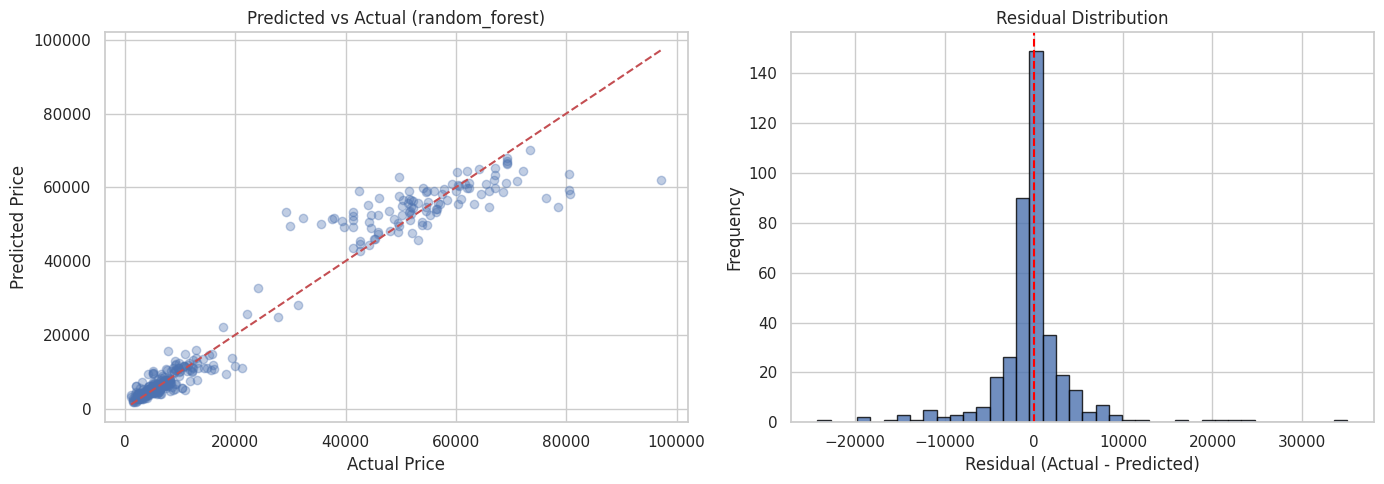

In [5]:
if best_pipeline is None:
    raise RuntimeError('No trained pipeline available.')

y_pred = best_pipeline.predict(X_test)
if USE_LOG_TARGET:
    y_pred = np.expm1(y_pred)

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.35)
min_v = min(float(y_test.min()), float(y_pred.min()))
max_v = max(float(y_test.max()), float(y_pred.max()))
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--')
axes[0].set_title(f'Predicted vs Actual ({best_model_name})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6) ROC-AUC view (optional business framing)
ROC-AUC is a **classification** metric, not a native regression metric.

To include it meaningfully here, we convert the regression target into a binary label:
- `1` = high-price flight (`price >= median(train_price)`)
- `0` = low-price flight

> We then use predicted price as the ranking score for the ROC curve.

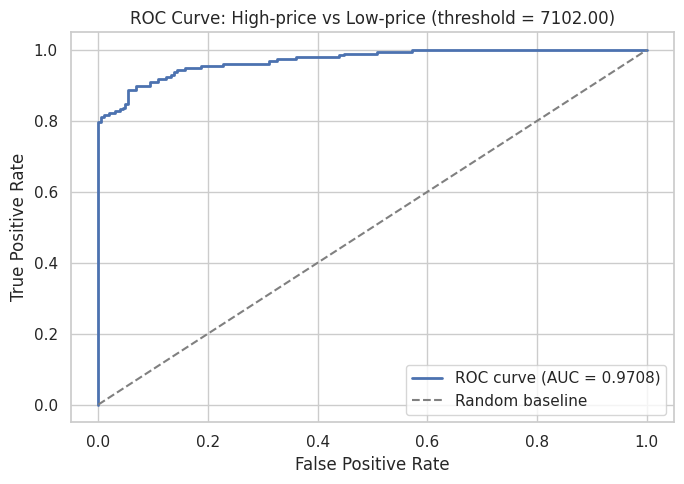

ROC-AUC (high-price classification view): 0.9708


In [6]:
# Convert regression target to binary classes using train median threshold
threshold = float(y_train.median())
y_test_binary = (y_test >= threshold).astype(int)

# Predicted price works as a continuous score for ranking high-price flights
y_score = y_pred

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: High-price vs Low-price (threshold = {threshold:.2f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC-AUC (high-price classification view): {roc_auc:.4f}')

## 6) Save results and best model pipeline

In [7]:
results_path = OUTPUT_DIR / 'model_comparison.csv'
results.to_csv(results_path, index=False)

with (OUTPUT_DIR / 'best_model.txt').open('w', encoding='utf-8') as f:
    f.write(str(best_model_name))

try:
    import joblib
    joblib.dump(best_pipeline, OUTPUT_DIR / 'best_model_pipeline.joblib')
    print('Saved: best_model_pipeline.joblib')
except ImportError:
    print('joblib not installed; skipped pipeline serialization.')

print(f'Saved: {results_path}')
print(f'Saved: {OUTPUT_DIR / "best_model.txt"}')

Saved: best_model_pipeline.joblib
Saved: outputs/flight_price/model_comparison.csv
Saved: outputs/flight_price/best_model.txt


## 7) Conclusion (write-up template)
- Best performing model: **`best_model_name`** (from the table above).
- Report these metrics in your submission: **Test RMSE, Test MAE, Test R²**.
- Add 2–3 observations from the residual plot (bias, spread, outliers).
- Mention one limitation (no external demand/seasonality features) and one improvement (hyperparameter tuning on top models).